In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# T-JEPA on Elliptic Bitcoin Fraud Detection

This notebook contains the complete experiment for applying a T-JEPA-inspired
self-supervised representation learning approach to the Elliptic Bitcoin
transaction dataset.

## Experiment Overview

The workflow consists of the following stages:

1. Load the Elliptic transaction features and class labels.
2. Merge the datasets using `txId`.
3. Keep transactions with known labels.
4. Create a chronological train/validation/test split using `time_step`.
5. Standardize transaction features using the training set.
6. Pretrain the T-JEPA model using masked-feature prediction.
7. Generate transaction embeddings using the learned context encoder.
8. Train a downstream binary fraud classifier on the embeddings.
9. Select the best classifier using validation Average Precision.
10. Evaluate the final classifier on the held-out test set.
11. Save evaluation metrics, predictions, plots, and the trained classifier.

## Important Label Mapping

For the final corrected experiment:

- `1` = Illicit / Fraud
- `0` = Licit / Legitimate

## Temporal Split

The experiment uses a chronological split based on `time_step`:

- Training: `time_step <= 34`
- Validation: `35 <= time_step <= 39`
- Test: `time_step >= 40`

This notebook is intended to provide a reproducible record of the experiment
and its evaluation procedure.

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [3]:
!pip install -q scikit-learn pandas matplotlib tqdm

In [4]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


In [5]:
DATA_DIR = "/kaggle/input/datasets/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

FEATURE_PATH = os.path.join(DATA_DIR, "elliptic_txs_features.csv")
CLASS_PATH = os.path.join(DATA_DIR, "elliptic_txs_classes.csv")
EDGE_PATH = os.path.join(DATA_DIR, "elliptic_txs_edgelist.csv")

features = pd.read_csv(FEATURE_PATH, header=None)
classes = pd.read_csv(CLASS_PATH)
edges = pd.read_csv(EDGE_PATH)

print("Features shape:", features.shape)
print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

display(features.head())
display(classes.head())
display(edges.head())

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [6]:
features.columns = ["txId", "time_step"] + [
    f"feature_{i}" for i in range(1, features.shape[1] - 1)
]

classes.columns = ["txId", "class"]

df = features.merge(classes, on="txId", how="inner")

df["class"] = df["class"].astype(str).str.strip()

df = df[df["class"].isin(["1", "2"])].copy()

df["label"] = df["class"].map({
    "1": 0,
    "2": 1
}).astype(int)

df = df.sort_values(["time_step", "txId"]).reset_index(drop=True)

feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

print("Labeled transactions:", len(df))
print("Feature count:", len(feature_cols))
print("\nClass distribution:")
print(df["label"].value_counts())

print("\nTime-step distribution:")
print(df.groupby("time_step")["label"].agg(["count", "sum"]).head(15))

Labeled transactions: 46564
Feature count: 165

Class distribution:
label
1    42019
0     4545
Name: count, dtype: int64

Time-step distribution:
           count   sum
time_step             
1           2147  2130
2           1117  1099
3           1279  1268
4           1440  1410
5           1882  1874
6            485   480
7           1203  1101
8           1165  1098
9            778   530
10           972   954
11           696   565
12           506   490
13           809   518
14           417   374
15           618   471


## Chronological Train / Validation / Test Split

The labeled transactions are divided chronologically using the `time_step`
field.

- Training set: `time_step <= 34`
- Validation set: `35 <= time_step <= 39`
- Test set: `time_step >= 40`

This chronological split is used instead of a random split so that later
time steps are kept separate from the training data.

The validation set is used for model selection, while the test set is
reserved for final evaluation.

In [7]:
train_df = df[df["time_step"] <= 34].copy()

val_df = df[
    (df["time_step"] >= 35) &
    (df["time_step"] <= 39)
].copy()

test_df = df[df["time_step"] >= 40].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nFraud counts:")
print("Train:", train_df["label"].sum())
print("Validation:", val_df["label"].sum())
print("Test:", test_df["label"].sum())

Train: (29894, 169)
Validation: (5486, 169)
Test: (11184, 169)

Fraud counts:
Train: 26432
Validation: 5039
Test: 10548


## Feature Preprocessing

Transaction feature values are standardized using `StandardScaler`.

The scaler is fitted **only on the training set** and then applied to the
validation and test sets.

Missing feature values are replaced with `0` before scaling.

This prevents information from the validation or test sets from being used
when fitting the preprocessing step.

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_df[feature_cols].fillna(0)
).astype(np.float32)

X_val = scaler.transform(
    val_df[feature_cols].fillna(0)
).astype(np.float32)

X_test = scaler.transform(
    test_df[feature_cols].fillna(0)
).astype(np.float32)

y_train = train_df["label"].to_numpy(dtype=np.int64)
y_val = val_df["label"].to_numpy(dtype=np.int64)
y_test = test_df["label"].to_numpy(dtype=np.int64)

t_train = train_df["time_step"].to_numpy(dtype=np.int64)
t_val = val_df["time_step"].to_numpy(dtype=np.int64)
t_test = test_df["time_step"].to_numpy(dtype=np.int64)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (29894, 165)
X_val: (5486, 165)
X_test: (11184, 165)


In [10]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, embedding_dim=128):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim + 16, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, x, time_embedding):
        return self.network(
            torch.cat([x, time_embedding], dim=1)
        )


class TJEPA(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, embedding_dim=128):
        super().__init__()

        self.time_embedding = nn.Embedding(50, 16)

        self.context_encoder = Encoder(
            input_dim, hidden_dim, embedding_dim
        )

        self.target_encoder = copy.deepcopy(
            self.context_encoder
        )

        for p in self.target_encoder.parameters():
            p.requires_grad = False

        self.predictor = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, x, time_step):
        time_emb = self.time_embedding(time_step)

        z_context = self.context_encoder(x, time_emb)

        with torch.no_grad():
            z_target = self.target_encoder(x, time_emb)

        prediction = self.predictor(z_context)

        return prediction, z_target, z_context

    @torch.no_grad()
    def update_target(self, momentum=0.996):
        for p_context, p_target in zip(
            self.context_encoder.parameters(),
            self.target_encoder.parameters()
        ):
            p_target.data.mul_(momentum).add_(
                p_context.data, alpha=1 - momentum
            )

In [11]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
t_train_tensor = torch.tensor(t_train, dtype=torch.long)

train_dataset = TensorDataset(
    X_train_tensor,
    t_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))

Training batches: 59


## T-JEPA Pretraining

The T-JEPA model is pretrained using a self-supervised objective on the
training transactions.

The model uses:

- Input features from the Elliptic transaction dataset
- A 16-dimensional time-step embedding
- Context encoder
- Target encoder
- Predictor network
- Random feature masking with probability `0.30`

The target encoder is updated using an exponential moving average (EMA)
with momentum `0.996`.

The pretraining configuration is:

- Hidden dimension: `256`
- Embedding dimension: `128`
- Batch size: `512`
- Learning rate: `1e-3`
- Weight decay: `1e-4`
- Epochs: `20`

The self-supervised loss compares normalized predicted and target
representations using mean squared error.

In [12]:
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM = 256
EMBEDDING_DIM = 128

EPOCHS = 20
LEARNING_RATE = 1e-3

model = TJEPA(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(model.context_encoder.parameters()) +
    list(model.predictor.parameters()) +
    list(model.time_embedding.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

history = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for xb, tb in progress:

        xb = xb.to(DEVICE, non_blocking=True)
        tb = tb.to(DEVICE, non_blocking=True)

        # Random feature masking
        mask = (
            torch.rand_like(xb) > 0.30
        ).float()

        x_masked = xb * mask

        prediction, target, _ = model(x_masked, tb)

        loss = F.mse_loss(
            F.normalize(prediction, dim=1),
            F.normalize(target, dim=1)
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        optimizer.step()
        model.update_target(momentum=0.996)

        total_loss += loss.item()

        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    history.append(avg_loss)

    print(f"Epoch {epoch + 1}: Loss = {avg_loss:.6f}")

Epoch 1/20:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1: Loss = 0.003664


Epoch 2/20:   0%|          | 0/59 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420>Exception ignored in: 
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    if w.is_alive():

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    assert self._parent_pid == os.getpid(), 'can only test a child process'    
if w.is_alive():AssertionError
:   File "/usr/lib/python3.13/multiprocessing/pro

Epoch 2: Loss = 0.000742


...

<function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420>Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()    
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'Exc

Epoch 19: Loss = 0.000013


Epoch 20/20:   0%|          | 0/59 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420><function _MultiProcessingDataLoaderIter.__del__ at 0x78e215ec3420>
Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.13/multiprocessing/process.py", line 16

Epoch 20: Loss = 0.000013


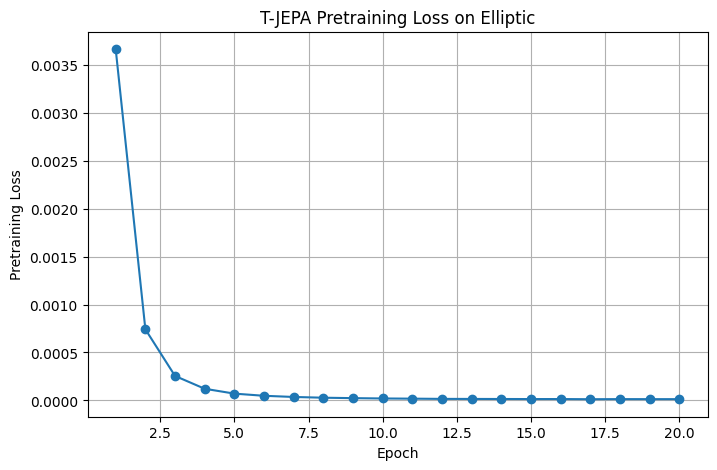

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history) + 1),
    history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Pretraining Loss")
plt.title("T-JEPA Pretraining Loss on Elliptic")
plt.grid(True)
plt.show()

In [14]:
OUTPUT_DIR = "/kaggle/working/tjepa_elliptic_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_checkpoint.pth"
)

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "embedding_dim": EMBEDDING_DIM,
    "epochs": EPOCHS,
    "feature_cols": feature_cols,
    "training_loss": history,
    "seed": SEED
}, CHECKPOINT_PATH)

print("Checkpoint saved:", CHECKPOINT_PATH)

Checkpoint saved: /kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_checkpoint.pth


## Transaction Embedding Extraction

After T-JEPA pretraining, the learned context encoder is used to generate
fixed-dimensional embeddings for the training, validation, and test
transactions.

The context encoder combines the standardized transaction features with
the corresponding time-step embedding.

These learned embeddings are then used as input to the downstream fraud
classification model.

In [15]:
@torch.no_grad()
def extract_embeddings(X, timesteps):

    model.eval()

    X_tensor = torch.tensor(
        X, dtype=torch.float32
    ).to(DEVICE)

    t_tensor = torch.tensor(
        timesteps, dtype=torch.long
    ).to(DEVICE)

    embeddings = []

    for start in range(0, len(X_tensor), 1024):

        xb = X_tensor[start:start + 1024]
        tb = t_tensor[start:start + 1024]

        time_emb = model.time_embedding(tb)

        z = model.context_encoder(xb, time_emb)

        embeddings.append(z.cpu().numpy())

    return np.concatenate(embeddings, axis=0)


Z_train = extract_embeddings(X_train, t_train)
Z_val = extract_embeddings(X_val, t_val)
Z_test = extract_embeddings(X_test, t_test)

print("Train embeddings:", Z_train.shape)
print("Validation embeddings:", Z_val.shape)
print("Test embeddings:", Z_test.shape)

Train embeddings: (29894, 128)
Validation embeddings: (5486, 128)
Test embeddings: (11184, 128)


## Downstream Fraud Classification

The embeddings generated by the pretrained T-JEPA context encoder are used
as input to a downstream binary fraud classifier.

The classifier is an MLP that predicts whether a transaction is:

- `1` = Illicit / Fraud
- `0` = Licit / Legitimate

Because the fraud class is highly imbalanced, the training loss uses
class-imbalance weighting.

The final classifier is selected using validation Average Precision, and the
held-out test set is used only for the final evaluation.

In [16]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


classifier = FraudMLP(Z_train.shape[1]).to(DEVICE)

positive_count = int(y_train.sum())
negative_count = len(y_train) - positive_count

pos_weight = torch.tensor(
    [negative_count / max(positive_count, 1)],
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer_cls = torch.optim.AdamW(
    classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Z_train_tensor = torch.tensor(Z_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

cls_loader = DataLoader(
    TensorDataset(Z_train_tensor, y_train_tensor),
    batch_size=512,
    shuffle=True
)

CLS_EPOCHS = 30

cls_history = []

for epoch in range(CLS_EPOCHS):

    classifier.train()
    total_loss = 0

    for zb, yb in cls_loader:

        zb = zb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = classifier(zb)
        loss = criterion(logits, yb)

        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(cls_loader)
    cls_history.append(avg_loss)

    print(
        f"Classifier Epoch {epoch + 1}/{CLS_EPOCHS}: "
        f"Loss = {avg_loss:.5f}"
    )

Classifier Epoch 1/30: Loss = 0.09844
Classifier Epoch 2/30: Loss = 0.06476
Classifier Epoch 3/30: Loss = 0.05696
Classifier Epoch 4/30: Loss = 0.05139
Classifier Epoch 5/30: Loss = 0.04597
Classifier Epoch 6/30: Loss = 0.04267
Classifier Epoch 7/30: Loss = 0.03901
Classifier Epoch 8/30: Loss = 0.03658
Classifier Epoch 9/30: Loss = 0.03334
Classifier Epoch 10/30: Loss = 0.03171
Classifier Epoch 11/30: Loss = 0.03048
Classifier Epoch 12/30: Loss = 0.02919
Classifier Epoch 13/30: Loss = 0.02761
Classifier Epoch 14/30: Loss = 0.02644
Classifier Epoch 15/30: Loss = 0.02402
Classifier Epoch 16/30: Loss = 0.02315
Classifier Epoch 17/30: Loss = 0.02286
Classifier Epoch 18/30: Loss = 0.02173
Classifier Epoch 19/30: Loss = 0.02075
Classifier Epoch 20/30: Loss = 0.02238
Classifier Epoch 21/30: Loss = 0.01973
Classifier Epoch 22/30: Loss = 0.01780
Classifier Epoch 23/30: Loss = 0.01766
Classifier Epoch 24/30: Loss = 0.01612
Classifier Epoch 25/30: Loss = 0.01632
Classifier Epoch 26/30: Loss = 0.0

In [17]:
@torch.no_grad()
def predict_probabilities(embeddings):

    classifier.eval()

    x = torch.tensor(
        embeddings,
        dtype=torch.float32
    ).to(DEVICE)

    probabilities = []

    for start in range(0, len(x), 1024):

        logits = classifier(x[start:start + 1024])

        probs = torch.sigmoid(logits)

        probabilities.append(probs.cpu().numpy())

    return np.concatenate(probabilities)


val_prob = predict_probabilities(Z_val)
test_prob = predict_probabilities(Z_test)

print("Validation predictions:", val_prob.shape)
print("Test predictions:", test_prob.shape)

Validation predictions: (5486,)
Test predictions: (11184,)


In [18]:
roc_auc = roc_auc_score(y_test, test_prob)
pr_auc = average_precision_score(y_test, test_prob)

test_pred_05 = (test_prob >= 0.5).astype(int)

print("Test ROC-AUC:", round(roc_auc, 4))
print("Test PR-AUC / Average Precision:", round(pr_auc, 4))

print("\nPrecision:", precision_score(y_test, test_pred_05, zero_division=0))
print("Recall:", recall_score(y_test, test_pred_05, zero_division=0))
print("F1:", f1_score(y_test, test_pred_05, zero_division=0))
print("Accuracy:", accuracy_score(y_test, test_pred_05))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_05))

print("\nClassification Report:")
print(classification_report(y_test, test_pred_05, zero_division=0))

Test ROC-AUC: 0.8176
Test PR-AUC / Average Precision: 0.9846

Precision: 0.9613367009908684
Recall: 0.9381873340917709
F1: 0.9496209576816045
Accuracy: 0.9061158798283262

Confusion Matrix:
[[ 238  398]
 [ 652 9896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.37      0.31       636
           1       0.96      0.94      0.95     10548

    accuracy                           0.91     11184
   macro avg       0.61      0.66      0.63     11184
weighted avg       0.92      0.91      0.91     11184



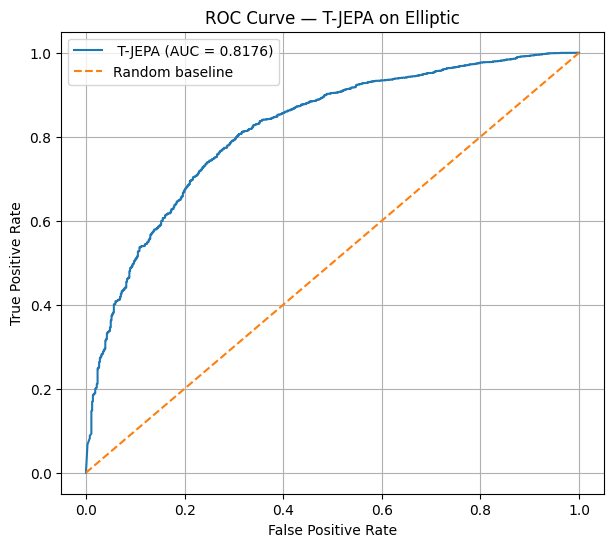

In [19]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f" T-JEPA (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — T-JEPA on Elliptic")
plt.legend()
plt.grid(True)
plt.savefig(
    os.path.join(OUTPUT_DIR, "tjepa_elliptic_roc_curve.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

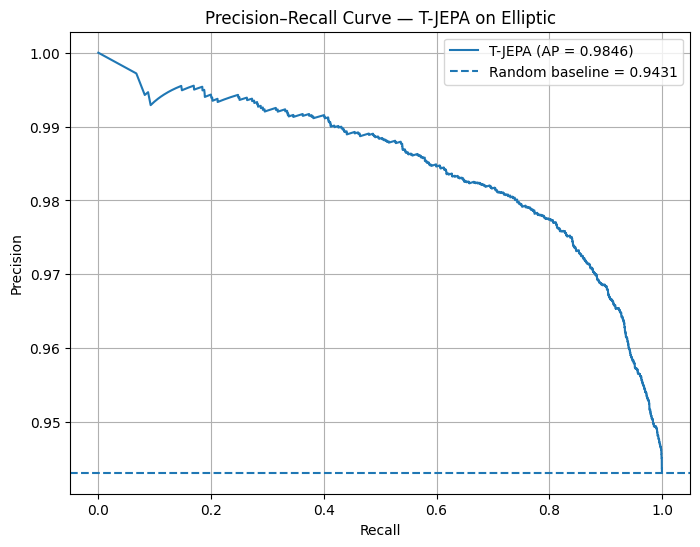

In [20]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"T-JEPA (AP = {pr_auc:.4f})"
)

baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — T-JEPA on Elliptic")
plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(OUTPUT_DIR, "tjepa_elliptic_pr_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
target_recalls = np.arange(0.1, 1.01, 0.1)

rows = []

for target_recall in target_recalls:

    eligible = np.where(recall >= target_recall)[0]

    if len(eligible) == 0:
        continue

    best_idx = eligible[
        np.argmax(precision[eligible])
    ]

    if best_idx < len(pr_thresholds):
        threshold = pr_thresholds[best_idx]
    else:
        threshold = 0.0

    predictions = (test_prob >= threshold).astype(int)

    rows.append({
        "Target Recall": target_recall,
        "Actual Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "Threshold": threshold
    })

pr_table = pd.DataFrame(rows)

display(
    pr_table.style.format({
        "Target Recall": "{:.2f}",
        "Actual Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "F1 Score": "{:.4f}",
        "Threshold": "{:.6f}"
    })
)

pr_table.to_csv(
    os.path.join(OUTPUT_DIR, "tjepa_precision_recall_table.csv"),
    index=False
)

,Target Recall,Actual Recall,Precision,F1 Score,Threshold
0,0.10,0.1693,0.9955,0.2894,0.999993
1,0.20,0.2479,0.9943,0.3969,0.999970
2,0.30,0.3149,0.9925,0.4782,0.999926
3,0.40,0.4006,0.9916,0.5707,0.999788
4,0.50,0.5036,0.9885,0.6673,0.999288
5,0.60,0.6057,0.9847,0.7501,0.997695
6,0.70,0.7032,0.9817,0.8194,0.992889
7,0.80,0.8023,0.9775,0.8813,0.969285
8,0.90,0.9009,0.9684,0.9335,0.796064
9,1.00,1.0000,0.9432,0.9708,0.000049


In [22]:
test_results = pd.DataFrame({
    "txId": test_df["txId"].values,
    "time_step": t_test,
    "y_true": y_test,
    "fraud_probability": test_prob,
    "predicted_label": (test_prob >= 0.5).astype(int)
})

PREDICTION_PATH = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_test_predictions.csv"
)

test_results.to_csv(PREDICTION_PATH, index=False)

print("Saved:", PREDICTION_PATH)

display(test_results.head())

Saved: /kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_test_predictions.csv


,txId,time_step,y_true,fraud_probability,predicted_label
0,172562,40,1,0.998052,1
1,797419,40,1,1.000000,1
2,880825,40,1,0.999999,1
3,886996,40,1,0.994594,1
4,905123,40,1,0.999992,1


In [23]:
CLASSIFIER_PATH = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_classifier.pth"
)

torch.save({
    "classifier_state_dict": classifier.state_dict(),
    "embedding_dim": Z_train.shape[1],
    "threshold": 0.5,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc
}, CLASSIFIER_PATH)

metrics = pd.DataFrame([{
    "Model": "T-JEPA + MLP",
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "Precision@0.5": precision_score(y_test, test_pred_05, zero_division=0),
    "Recall@0.5": recall_score(y_test, test_pred_05, zero_division=0),
    "F1@0.5": f1_score(y_test, test_pred_05, zero_division=0),
    "Test Samples": len(y_test),
    "Fraud Samples": int(y_test.sum())
}])

metrics.to_csv(
    os.path.join(OUTPUT_DIR, "tjepa_elliptic_metrics.csv"),
    index=False
)

display(metrics)

,Model,ROC-AUC,PR-AUC,Precision@0.5,Recall@0.5,F1@0.5,Test Samples,Fraud Samples
0,T-JEPA + MLP,0.817566,0.984625,0.961337,0.938187,0.949621,11184,10548


In [24]:
print("FINAL OUTPUT FILES\n")

for root, dirs, files in os.walk(OUTPUT_DIR):
    for file in files:
        path = os.path.join(root, file)
        print(file, "|", round(os.path.getsize(path) / 1024, 2), "KB")

FINAL OUTPUT FILES

tjepa_elliptic_classifier.pth | 261.73 KB
tjepa_precision_recall_table.csv | 0.77 KB
tjepa_elliptic_metrics.csv | 0.2 KB
tjepa_elliptic_checkpoint.pth | 1417.13 KB
tjepa_elliptic_pr_curve.png | 130.63 KB
tjepa_elliptic_test_predictions.csv | 287.46 KB
tjepa_elliptic_roc_curve.png | 131.01 KB


In [25]:
print("Original Elliptic class distribution:")
print(df["class"].value_counts())

print("\nCurrent label mapping:")
print(df.groupby("class")["label"].agg(["count", "sum"]))

print("\nTest class distribution:")
print(test_df["class"].value_counts())

Original Elliptic class distribution:
class
2    42019
1     4545
Name: count, dtype: int64

Current label mapping:
       count    sum
class              
1       4545      0
2      42019  42019

Test class distribution:
class
2    10548
1      636
Name: count, dtype: int64


## Final Corrected Experiment

The cells below contain the final corrected fraud-detection experiment.

An earlier experiment in this notebook used an initial label mapping and classifier configuration.
The final experiment corrects the binary label mapping and retrains the downstream classifier
using validation-based model selection.

For the final experiment:

- `1` = Illicit / Fraud
- `0` = Licit / Legitimate

The final classifier uses T-JEPA embeddings, class-imbalance weighting, validation Average
Precision for model selection, and early stopping.

The results reported in the repository documentation are generated by the corrected experiment
below this section.

In [26]:
# Correct fraud labels
df["label"] = df["class"].astype(str).map({
    "1": 1,  # Illicit / fraud
    "2": 0   # Licit / legitimate
}).astype(int)

# Recreate chronological splits
train_df = df[df["time_step"] <= 34].copy()

val_df = df[
    (df["time_step"] >= 35) &
    (df["time_step"] <= 39)
].copy()

test_df = df[df["time_step"] >= 40].copy()

# Correct target arrays
y_train = train_df["label"].to_numpy(dtype="int64")
y_val = val_df["label"].to_numpy(dtype="int64")
y_test = test_df["label"].to_numpy(dtype="int64")

print("Corrected label distribution:")
print(df.groupby("class")["label"].agg(["count", "sum"]))

print("\nTrain:", len(y_train), "Fraud:", y_train.sum())
print("Validation:", len(y_val), "Fraud:", y_val.sum())
print("Test:", len(y_test), "Fraud:", y_test.sum())

print("\nEmbedding and label lengths:")
print("Train:", len(Z_train), len(y_train))
print("Validation:", len(Z_val), len(y_val))
print("Test:", len(Z_test), len(y_test))

assert len(Z_train) == len(y_train)
assert len(Z_val) == len(y_val)
assert len(Z_test) == len(y_test)

print("\nLength checks passed.")

Corrected label distribution:
       count   sum
class             
1       4545  4545
2      42019     0

Train: 29894 Fraud: 3462
Validation: 5486 Fraud: 447
Test: 11184 Fraud: 636

Embedding and label lengths:
Train: 29894 29894
Validation: 5486 5486
Test: 11184 11184

Length checks passed.


In [27]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import average_precision_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Convert embeddings and labels to tensors
X_train = torch.tensor(np.asarray(Z_train), dtype=torch.float32)
X_val = torch.tensor(np.asarray(Z_val), dtype=torch.float32)

Y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
Y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# MLP classifier
class FraudClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

classifier = FraudClassifier(X_train.shape[1]).to(device)

# Compensate for class imbalance
positive_count = int(y_train.sum())
negative_count = len(y_train) - positive_count

pos_weight = torch.tensor(
    [negative_count / positive_count],
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=256,
    shuffle=True
)

# Train with validation-based model selection
best_val_ap = -1
best_state = None
patience = 5
epochs_without_improvement = 0

for epoch in range(30):
    classifier.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = classifier(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)

    classifier.eval()
    with torch.no_grad():
        val_logits = classifier(X_val.to(device))
        val_prob = torch.sigmoid(val_logits).cpu().numpy().ravel()

    val_ap = average_precision_score(y_val, val_prob)
    avg_loss = total_loss / len(X_train)

    print(
        f"Epoch {epoch+1:02d}/30 | "
        f"Loss: {avg_loss:.4f} | "
        f"Validation AP: {val_ap:.4f}"
    )

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in classifier.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping.")
        break

classifier.load_state_dict(best_state)
classifier.eval()

print("\nBest validation Average Precision:", round(best_val_ap, 4))
print("Classifier training completed.")

Device: cuda
Epoch 01/30 | Loss: 0.7570 | Validation AP: 0.3608
Epoch 02/30 | Loss: 0.4965 | Validation AP: 0.4495
Epoch 03/30 | Loss: 0.4494 | Validation AP: 0.5504
Epoch 04/30 | Loss: 0.4047 | Validation AP: 0.4978
Epoch 05/30 | Loss: 0.3779 | Validation AP: 0.5191
Epoch 06/30 | Loss: 0.3516 | Validation AP: 0.5793
Epoch 07/30 | Loss: 0.3251 | Validation AP: 0.5513
Epoch 08/30 | Loss: 0.3117 | Validation AP: 0.6075
Epoch 09/30 | Loss: 0.2999 | Validation AP: 0.6171
Epoch 10/30 | Loss: 0.2831 | Validation AP: 0.6118
Epoch 11/30 | Loss: 0.2743 | Validation AP: 0.5572
Epoch 12/30 | Loss: 0.2585 | Validation AP: 0.5853
Epoch 13/30 | Loss: 0.2522 | Validation AP: 0.6102
Epoch 14/30 | Loss: 0.2481 | Validation AP: 0.6313
Epoch 15/30 | Loss: 0.2332 | Validation AP: 0.6502
Epoch 16/30 | Loss: 0.2243 | Validation AP: 0.5827
Epoch 17/30 | Loss: 0.2202 | Validation AP: 0.6126
Epoch 18/30 | Loss: 0.2093 | Validation AP: 0.5677
Epoch 19/30 | Loss: 0.2048 | Validation AP: 0.6419
Epoch 20/30 | Loss

## Final Test Evaluation

The best classifier selected using validation Average Precision is evaluated
on the held-out test set.

The final predictions use a classification threshold of `0.50`.

The experiment reports:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision (PR-AUC)

The test set is not used for model selection or training.

TEST RESULTS
----------------------------------------
ROC-AUC: 0.8421
PR-AUC / Average Precision: 0.4980
Precision: 0.2809
Recall: 0.6211
F1 Score: 0.3869
Accuracy: 0.8881

Confusion Matrix:
[[9537 1011]
 [ 241  395]]

Classification Report:
                   precision    recall  f1-score   support

        Licit (0)       0.98      0.90      0.94     10548
Illicit/Fraud (1)       0.28      0.62      0.39       636

         accuracy                           0.89     11184
        macro avg       0.63      0.76      0.66     11184
     weighted avg       0.94      0.89      0.91     11184



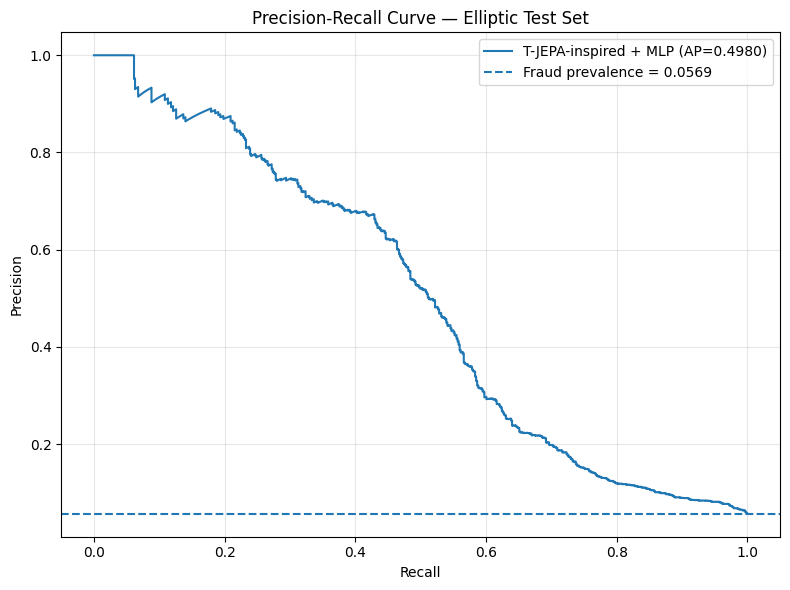


DISCRETE PRECISION-RECALL TABLE


,Target Recall,Actual Recall,Precision,F1 Score,Threshold,Predicted Positives
0,0.1,0.1085,0.9200,0.1941,0.9896,75
1,0.2,0.2091,0.8750,0.3376,0.9785,152
2,0.3,0.3019,0.7471,0.4300,0.9590,257
3,0.4,0.4009,0.6800,0.5045,0.9367,375
4,0.5,0.5000,0.5213,0.5104,0.8512,610
5,0.6,0.6006,0.2975,0.3979,0.5427,1284
6,0.7,0.7013,0.1986,0.3095,0.2741,2246
7,0.8,0.8003,0.1196,0.2081,0.0762,4255
8,0.9,0.9009,0.0899,0.1634,0.0233,6376
9,1.0,1.0000,0.0580,0.1096,0.0000,10969



Corrected files saved:
/kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_pr_curve_corrected.png
/kaggle/working/tjepa_elliptic_outputs/tjepa_precision_recall_table_corrected.csv
/kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_metrics_corrected.csv
/kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_test_predictions_corrected.csv
/kaggle/working/tjepa_elliptic_outputs/tjepa_elliptic_classifier_corrected.pth


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Output folder
OUTPUT_DIR = "/kaggle/working/tjepa_elliptic_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Test embeddings
X_test = torch.tensor(np.asarray(Z_test), dtype=torch.float32)

# Predict using best validation-selected classifier
classifier.eval()

with torch.no_grad():
    test_logits = classifier(X_test.to(device))
    test_prob = torch.sigmoid(test_logits).cpu().numpy().ravel()

# Standard threshold = 0.50
test_pred = (test_prob >= 0.50).astype(int)

# Final metrics
test_roc_auc = roc_auc_score(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)

print("TEST RESULTS")
print("-" * 40)
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC / Average Precision: {test_ap:.4f}")
print(f"Precision: {precision_score(y_test, test_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, test_pred, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, test_pred, zero_division=0):.4f}")
print(f"Accuracy: {accuracy_score(y_test, test_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred,
    target_names=["Licit (0)", "Illicit/Fraud (1)"],
    zero_division=0
))

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"T-JEPA-inspired + MLP (AP={test_ap:.4f})")
plt.axhline(
    y=np.mean(y_test),
    linestyle="--",
    label=f"Fraud prevalence = {np.mean(y_test):.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Elliptic Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(OUTPUT_DIR, "tjepa_elliptic_pr_curve_corrected.png")
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

# Discrete precision-recall table
target_recalls = np.arange(0.1, 1.01, 0.1)
rows = []

# precision_recall_curve has one extra precision/recall point,
# so thresholds align with precision[:-1] and recall[:-1].
for target in target_recalls:
    eligible = np.where(recall[:-1] >= target)[0]

    if len(eligible) == 0:
        continue

    # Select the highest precision among thresholds meeting target recall.
    best_precision = np.max(precision[eligible])
    tied = eligible[precision[eligible] == best_precision]

    # If tied, choose the highest threshold.
    best_idx = tied[np.argmax(thresholds[tied])]

    threshold = thresholds[best_idx]
    pred_at_threshold = (test_prob >= threshold).astype(int)

    rows.append({
        "Target Recall": round(float(target), 2),
        "Actual Recall": recall_score(
            y_test, pred_at_threshold, zero_division=0
        ),
        "Precision": precision_score(
            y_test, pred_at_threshold, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, pred_at_threshold, zero_division=0
        ),
        "Threshold": float(threshold),
        "Predicted Positives": int(pred_at_threshold.sum())
    })

pr_table = pd.DataFrame(rows)

print("\nDISCRETE PRECISION-RECALL TABLE")
display(pr_table.round(4))

table_path = os.path.join(
    OUTPUT_DIR,
    "tjepa_precision_recall_table_corrected.csv"
)
pr_table.to_csv(table_path, index=False)

# Save final metrics
metrics_df = pd.DataFrame([{
    "ROC_AUC": test_roc_auc,
    "PR_AUC_Average_Precision": test_ap,
    "Precision_at_0.50": precision_score(y_test, test_pred, zero_division=0),
    "Recall_at_0.50": recall_score(y_test, test_pred, zero_division=0),
    "F1_at_0.50": f1_score(y_test, test_pred, zero_division=0),
    "Accuracy_at_0.50": accuracy_score(y_test, test_pred),
    "Test_transactions": len(y_test),
    "Test_fraud_transactions": int(y_test.sum())
}])

metrics_path = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_metrics_corrected.csv"
)
metrics_df.to_csv(metrics_path, index=False)

# Save predictions
predictions_df = pd.DataFrame({
    "txId": test_df["txId"].to_numpy(),
    "true_label": y_test,
    "fraud_probability": test_prob,
    "predicted_label_at_0.50": test_pred
})

predictions_path = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_test_predictions_corrected.csv"
)
predictions_df.to_csv(predictions_path, index=False)

# Save corrected classifier
classifier_path = os.path.join(
    OUTPUT_DIR,
    "tjepa_elliptic_classifier_corrected.pth"
)
torch.save(classifier.state_dict(), classifier_path)

print("\nCorrected files saved:")
print(pr_path)
print(table_path)
print(metrics_path)
print(predictions_path)
print(classifier_path)